# Robustness analysis with bootstrap in the 10x Visium HD CRC dataset

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Nature Communications style
mpl.rcParams.update({
    'font.family'       : 'Helvetica',
    'font.size'         : 7,
    'axes.titlesize'    : 8,
    'axes.labelsize'    : 7,
    'xtick.labelsize'   : 6.5,
    'ytick.labelsize'   : 6.5,
    'axes.linewidth'    : 0.5,
    'xtick.major.width' : 0.5,
    'ytick.major.width' : 0.5,
    'xtick.major.size'  : 2.5,
    'ytick.major.size'  : 2.5,
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'savefig.dpi'       : 300,
    'figure.dpi'        : 150,
})

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
RESULT_PATH   = '/import/home2/share/yqzeng/MacSGP/results/CRC/bootstrap'
ORIGINAL_PATH = '/home/yzengbj/my_project/results/CRC'
FIG_PATH      = os.path.join(RESULT_PATH, 'figures_CI')
os.makedirs(FIG_PATH, exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────
prefix = 'adata_result_bootstrap_'
ALPHA  = 0.05   # → 95% CI
TOP_N  = 100

# ── Cell type lists ───────────────────────────────────────────────────────────
SELECTED_CELLTYPES = [
    'CAF', 'Enterocyte', 'Goblet', 'Macrophage',
    'Myofibroblast', 'Neutrophil', 'Pericytes', 'Plasma',
    'Proliferating Fibroblast', 'Proliferating Immune II',
    'Tumor III', 'Tumor V', 'cDC I', 'vSM',
]

# Programs kept after quality filtering (remove Myofibroblast / Prolif.Imm.II / cDC I)
filtered_cts = [
    'CAF', 'Enterocyte', 'Goblet', 'Macrophage',
    'Neutrophil', #'Pericytes', 
    'Plasma',
    'Proliferating Fibroblast',
    'Tumor III', 'Tumor V', 'vSM',
]

print(f'FIG_PATH: {FIG_PATH}')
print(f'Plotting {len(filtered_cts)} cell types: {filtered_cts}')

FIG_PATH: /import/home2/share/yqzeng/MacSGP/results/CRC/bootstrap/figures_CI
Plotting 10 cell types: ['CAF', 'Enterocyte', 'Goblet', 'Macrophage', 'Neutrophil', 'Plasma', 'Proliferating Fibroblast', 'Tumor III', 'Tumor V', 'vSM']


In [4]:
# ── Load original (non-bootstrap) result ──────────────────────────────────────
adata_orig   = ad.read_h5ad(os.path.join(ORIGINAL_PATH, 'adata_hd_016.h5ad'))
loading_orig = adata_orig.varm['loading']
gene_names   = np.array(adata_orig.var_names)

if hasattr(loading_orig, 'columns'):
    celltype_names   = list(loading_orig.columns)
    loading_orig_arr = loading_orig.values
elif hasattr(loading_orig, 'dtype') and loading_orig.dtype.names:
    celltype_names   = list(loading_orig.dtype.names)
    loading_orig_arr = np.column_stack([loading_orig[ct] for ct in celltype_names])
else:
    celltype_names   = [f'CT_{i}' for i in range(loading_orig.shape[1])]
    loading_orig_arr = np.array(loading_orig)

print(f'Genes: {len(gene_names)},  Cell types: {len(celltype_names)}')
print(f'Available cell types: {celltype_names}')

Genes: 2780,  Cell types: 22
Available cell types: ['CAF', 'CD8 T cell', 'Endothelial', 'Enteric Glial', 'Enterocyte', 'Fibroblast', 'Goblet', 'Lymphatic Endothelial', 'Macrophage', 'Myofibroblast', 'Neutrophil', 'Pericytes', 'Plasma', 'Proliferating Fibroblast', 'Proliferating Immune II', 'Proliferating Macrophages', 'Tuft', 'Tumor III', 'Tumor V', 'cDC I', 'mRegDC', 'vSM']


In [8]:
# ── Load all bootstrap h5ad files ─────────────────────────────────────────────
result_files = sorted([
    f for f in os.listdir(RESULT_PATH)
    if f.startswith(prefix) and f.endswith('.h5ad')
])
print(f'Found {len(result_files)} bootstrap files.')

boot_stack = []
for fname in result_files:
    adata_b = ad.read_h5ad(os.path.join(RESULT_PATH, fname))
    lb = adata_b.varm['loading']
    if hasattr(lb, 'values'):
        arr = lb.values
    elif hasattr(lb, 'dtype') and lb.dtype.names:
        arr = np.column_stack([lb[ct] for ct in celltype_names])
    else:
        arr = np.array(lb)
    boot_stack.append(arr)

boot_stack = np.array(boot_stack)          # (n_boot, n_genes, n_ct)
n_boot, n_genes, n_ct_all = boot_stack.shape
print(f'Bootstrap array shape: {boot_stack.shape}')

# ── Sign correction: align each bootstrap sample with the original ─────────────
for b in range(n_boot):
    for c in range(n_ct_all):
        corr, _ = pearsonr(boot_stack[b, :, c], loading_orig_arr[:, c])
        if corr < 0:
            boot_stack[b, :, c] *= -1

print('Sign correction done.')

Found 50 bootstrap files.
Bootstrap array shape: (50, 2780, 22)
Sign correction done.


In [9]:
def jaccard(s1, s2):
    inter = len(s1 & s2)
    union = len(s1 | s2)
    return inter / union if union > 0 else 0

def get_top_genes(loading_arr, gene_names, ct_idx, top_n):
    top_idx = np.argsort(np.abs(loading_arr[:, ct_idx]))[::-1][:top_n]
    return set(gene_names[top_idx])

selected_ct_indices = [(celltype_names.index(ct), ct) for ct in filtered_cts]

results = []
for top_n in [50, 100, 200]:
    for ct_idx, ct_name in selected_ct_indices:
        orig_top = get_top_genes(loading_orig_arr, gene_names, ct_idx, top_n)
        jaccards = [
            jaccard(orig_top, get_top_genes(boot_arr, gene_names, ct_idx, top_n))
            for boot_arr in boot_stack
        ]
        results.append({
            'cell_type'     : ct_name,
            'top_n'         : top_n,
            'mean_jaccard'  : np.mean(jaccards),
            'median_jaccard': np.median(jaccards),
            'std_jaccard'   : np.std(jaccards),
            'jaccards'      : jaccards,
        })

results_df = pd.DataFrame(results)

print('=== Jaccard Stability Summary (Top 50) ===')
print(results_df[results_df['top_n'] == 50][
    ['cell_type', 'mean_jaccard', 'median_jaccard', 'std_jaccard']
].to_string(index=False))

=== Jaccard Stability Summary (Top 50) ===
               cell_type  mean_jaccard  median_jaccard  std_jaccard
                     CAF      0.894454        0.886792     0.031196
              Enterocyte      0.945212        0.960784     0.029345
                  Goblet      0.910516        0.923077     0.035510
              Macrophage      0.919901        0.923077     0.031411
              Neutrophil      0.883860        0.886792     0.034200
                  Plasma      0.849743        0.851852     0.049207
Proliferating Fibroblast      0.859223        0.851852     0.030048
               Tumor III      0.917809        0.923077     0.034828
                 Tumor V      0.911406        0.923077     0.039525
                     vSM      0.860312        0.851852     0.040660


In [11]:
gene_recovery = []
for ct_idx, ct_name in selected_ct_indices:
    orig_top    = get_top_genes(loading_orig_arr, gene_names, ct_idx, TOP_N)
    gene_counts = {g: 0 for g in orig_top}
    for boot_arr in boot_stack:
        boot_top = get_top_genes(boot_arr, gene_names, ct_idx, TOP_N)
        for g in orig_top:
            if g in boot_top:
                gene_counts[g] += 1
    for gene, count in gene_counts.items():
        gene_recovery.append({
            'cell_type'    : ct_name,
            'gene'         : gene,
            'recovery_rate': count / n_boot,
        })

gene_recovery_df = pd.DataFrame(gene_recovery)

core = gene_recovery_df[gene_recovery_df['recovery_rate'] >= 0.8]
print(f'Core genes (recovery >= 80%, top {TOP_N}):')
for _, ct_name in selected_ct_indices:
    n_core = len(core[core['cell_type'] == ct_name])
    print(f'  {ct_name}: {n_core}/{TOP_N}')

Core genes (recovery >= 80%, top 100):
  CAF: 88/100
  Enterocyte: 94/100
  Goblet: 91/100
  Macrophage: 88/100
  Neutrophil: 80/100
  Plasma: 79/100
  Proliferating Fibroblast: 84/100
  Tumor III: 93/100
  Tumor V: 88/100
  vSM: 89/100


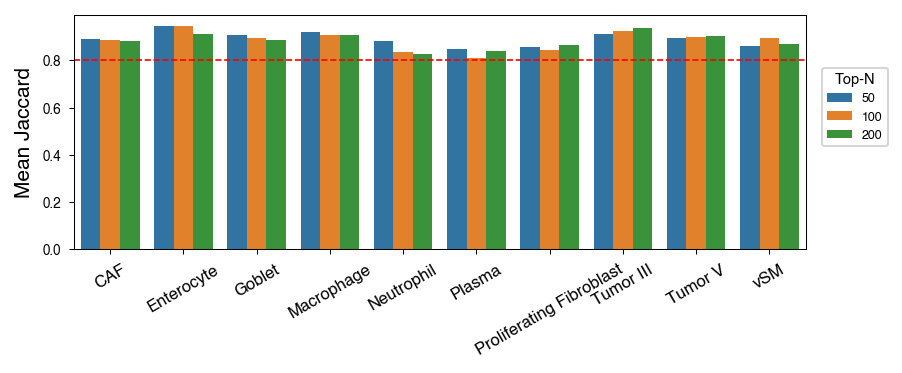

In [9]:
# Fig 2: Mean Jaccard comparison across top-N thresholds
summary = results_df[['cell_type', 'top_n', 'mean_jaccard']].copy()
summary = summary[summary['cell_type'].isin(filtered_cts)]
summary['top_n'] = summary['top_n'].astype(str)

fig, ax = plt.subplots(figsize=(6, 2.5))
sns.barplot(data=summary, x='cell_type', y='mean_jaccard',
            hue='top_n', ax=ax, order=filtered_cts)
ax.axhline(y=0.8, color='Red', linestyle='--', alpha=1, linewidth=0.8)
#ax.set_title('Stability across Top-N')
ax.set_ylabel('Mean Jaccard', fontsize=10)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.legend(title='Top-N', fontsize=6, title_fontsize=7, loc='upper right', bbox_to_anchor=(1.12, 0.8))
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig2_stability_topN.pdf'), bbox_inches='tight')
plt.show()

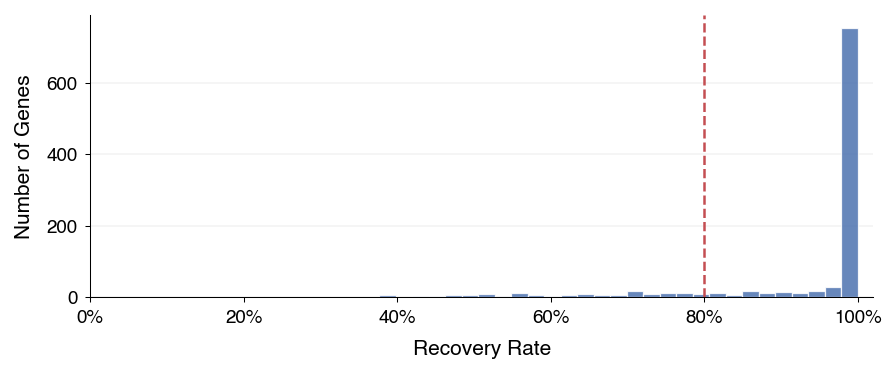

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
fig, ax = plt.subplots(figsize=(6, 2.5), dpi=150)

# ── histogram ──
counts, bins, patches = ax.hist(
    gene_recovery_df['recovery_rate'],
    bins=40,
    edgecolor='white',
    linewidth=0.6,
    color='#4C72B0',
    alpha=0.85,
    zorder=2,
)

for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 0.8:
        patch.set_facecolor('#4C72B0')  
        patch.set_alpha(0.85)

ax.axvline(x=0.8, color='#C44E52', linestyle='--', linewidth=1.2, zorder=3)

# ── axis labels ──
ax.set_xlabel('Recovery Rate', fontsize=10, labelpad=6)
ax.set_ylabel('Number of Genes', fontsize=10, labelpad=6)
ax.set_xlim(0, 1.02)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.grid(True, linestyle='-', alpha=0.15, zorder=0)
ax.set_axisbelow(Tru
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.tick_params(labelsize=9)

plt.tight_layout()
# plt.savefig(os.path.join(FIG_PATH, 'fig3_gene_recovery.pdf'),
#             bbox_inches='tight', dpi=300)
plt.show()

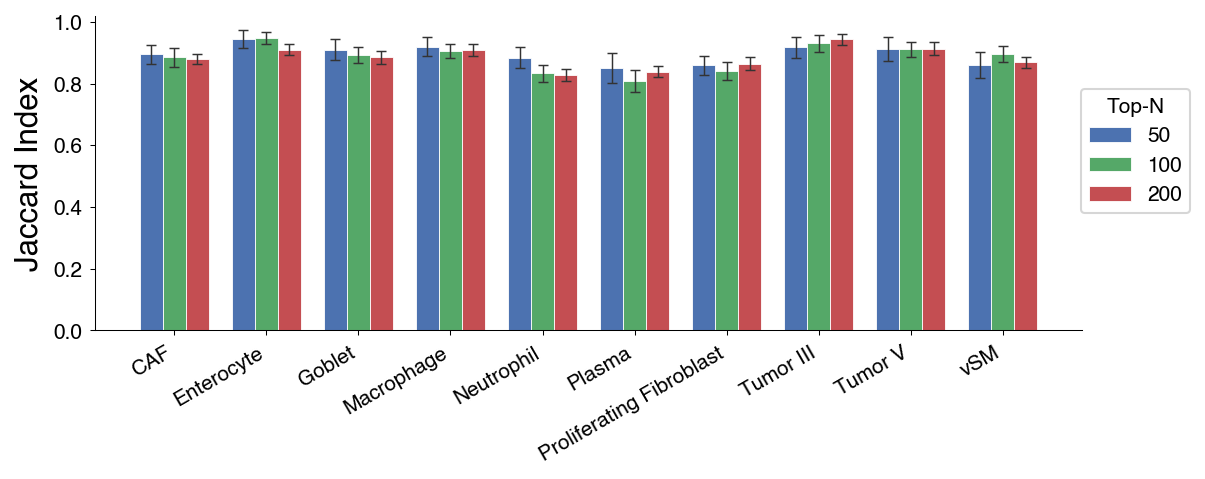

In [16]:
# ── Fig 1b: Jaccard mean ± SD  —  Top-50 / 100 / 200 grouped bar with error bars
top_n_vals = [50, 100, 200]
colors     = ['#4C72B0', '#55A868', '#C44E52']
n_cts      = len(filtered_cts)
x          = np.arange(n_cts)
w          = 0.25

fig, ax = plt.subplots(figsize=(8, 3.2))
for i, (top_n, color) in enumerate(zip(top_n_vals, colors)):
    sub = (results_df[results_df['top_n'] == top_n]
           .pipe(lambda d: d[d['cell_type'].isin(filtered_cts)])
           .set_index('cell_type')
           .loc[filtered_cts])
    ax.bar(
        x + (i - 1) * w, sub['mean_jaccard'], yerr=sub['std_jaccard'],
        width=w, capsize=2.5, label=f'{top_n}',
        color=color, edgecolor='white', linewidth=0.4,
        error_kw=dict(elinewidth=0.7, capthick=0.7, ecolor='#333333'),
    )

#ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=10)
ax.set_ylabel('Jaccard Index', fontsize=15)
ax.set_ylim(0, 1.02)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, title='Top-N', title_fontsize=10, 
          loc='upper right', bbox_to_anchor=(1.12, 0.8), 
          )
plt.tight_layout()
#plt.savefig(os.path.join(FIG_PATH, 'fig1b_jaccard_errorbar_topN.pdf'), bbox_inches='tight')
plt.show()

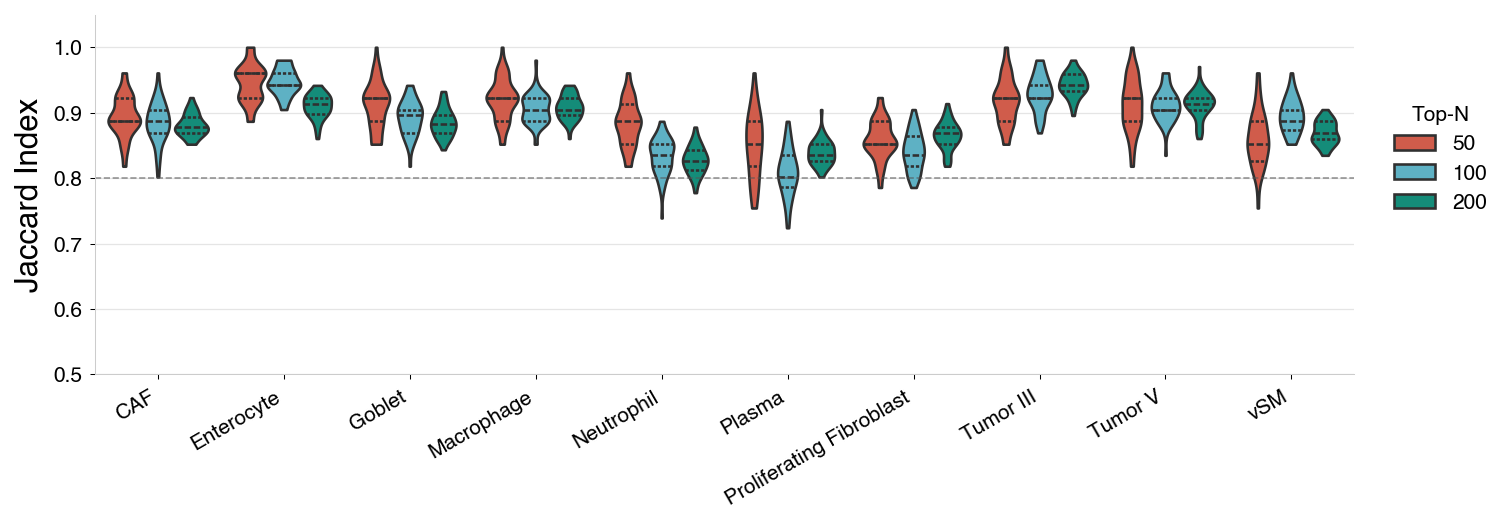

In [ ]:
# ── Fig 1c: Jaccard — grouped violin plot (beautified) ────────────────────────
jac_long = []
for _, row in results_df.iterrows():
    if row['cell_type'] not in filtered_cts:
        continue
    for j in row['jaccards']:
        jac_long.append({
            'cell_type': row['cell_type'],
            'top_n'    : str(int(row['top_n'])),
            'Jaccard'  : j,
        })
jac_long_df = pd.DataFrame(jac_long)

palette = ['#E64B35', '#4DBBD5', '#00A087']

fig, ax = plt.subplots(figsize=(10, 3.5))

sns.violinplot(
    data=jac_long_df,
    x='cell_type', y='Jaccard',
    hue='top_n', hue_order=['50', '100', '200'],
    order=filtered_cts,
    palette=palette,
    inner='quartile',  
    cut=0,
    #linewidth=0,
    ax=ax,
)


ax.axhline(y=0.8, color='#555555', linestyle='--', linewidth=0.8, alpha=0.6)
ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0.5, 1.05)
ax.set_xticks(range(len(filtered_cts)))
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=10)
ax.set_ylabel('Jaccard Index', fontsize=15)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.legend(fontsize=10, title='Top-N', title_fontsize=10,
          loc='upper right', bbox_to_anchor=(1.12, 0.8),
          framealpha=0.9, edgecolor='none')
plt.tight_layout()
#plt.savefig(os.path.join(FIG_PATH, 'fig1c_jaccard_violin.pdf'), bbox_inches='tight')
plt.show()

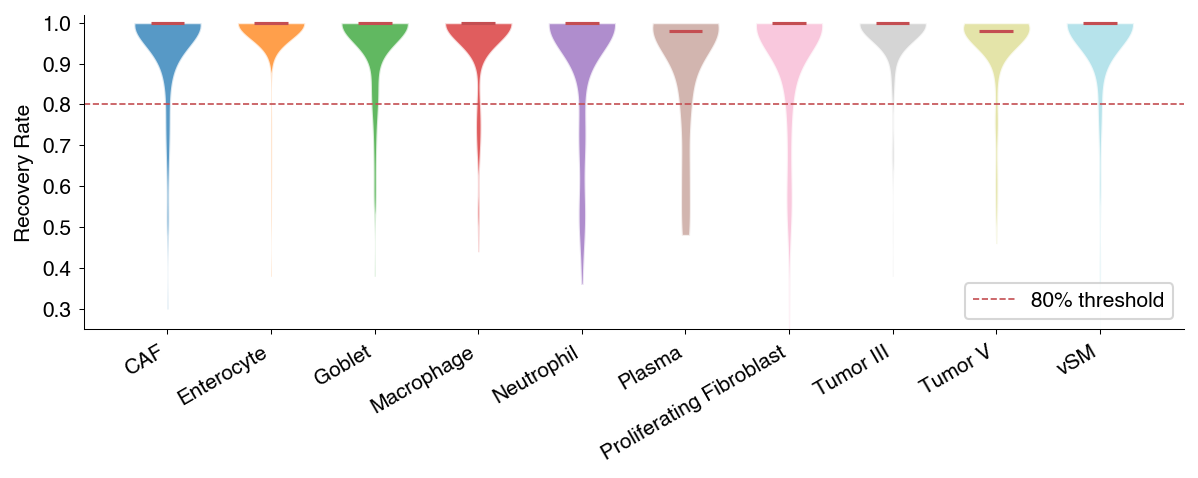

In [10]:
# ── Fig 3b: Recovery rate violin per cell type ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.2))
violin_data = [
    gene_recovery_df[gene_recovery_df['cell_type'] == ct]['recovery_rate'].values
    for ct in filtered_cts
]
cmap = plt.cm.get_cmap('tab20', n_cts)
parts = ax.violinplot(
    violin_data,
    positions=np.arange(n_cts),
    showmedians=True, showextrema=False, widths=0.65,
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(cmap(i))
    pc.set_edgecolor('white')
    pc.set_alpha(0.75)
parts['cmedians'].set_color('#C44E52')
parts['cmedians'].set_linewidth(1.5)
# for key in ('cmins', 'cmaxes', 'cbars'):
#     parts[key].set_linewidth(0.8)
#     parts[key].set_color('#333333')

ax.axhline(y=0.8, color='#C44E52', linestyle='--', linewidth=0.8, label='80% threshold')
ax.set_xticks(np.arange(n_cts))
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Recovery Rate', fontsize=10)
ax.set_ylim(0.25, 1.02)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=10)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig3b_recovery_violin.pdf'), bbox_inches='tight')
plt.show()